In [1]:
import scripts.jupyter_config as jupyter_config
from src import sample_data_preperation
sample_data_preperation.main()

2026-08-31 16:56:37.007 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /Users/gordon/Documents/GitHub/ECON138-Final-Paper


2026-08-31 16:56:37.149 | INFO     | src.sample_data_preperation:main:20 - Processing fred dataset...
2026-08-31 16:56:37.166 | INFO     | src.sample_data_preperation:main:24 - Processing yfinance dataset...
2026-08-31 16:56:37.613 | INFO     | src.sample_data_preperation:main:29 - Processing model dataset...
2026-08-31 16:56:37.619 | SUCCESS  | src.sample_data_preperation:main:34 - Processing dataset complete.


In [78]:
%%R
source("../scripts/init.R")
source("../scripts/read_data.R")
source("../scripts/stock_ts.R")

Plot variable not specified, automatically selected `.vars = PCU484484`


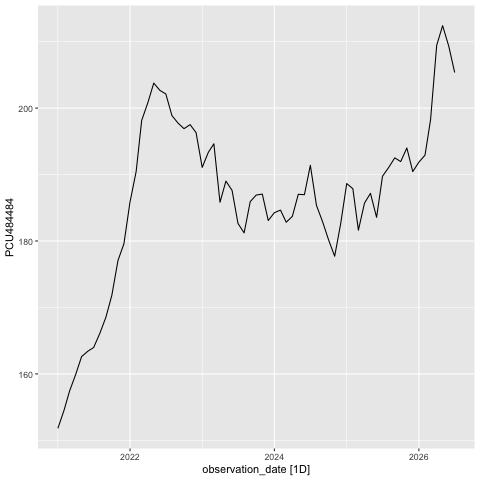

In [3]:
%%R
fred$observation_date <- as.Date(fred$observation_date, format = "%Y-%m-%d")
skim(fred)
fred_ts <- tsibble(fred, index = observation_date)
autoplot(fred_ts)

In [4]:
%%R
# Sumary Stats, autoplot
stock$observation_date <- as.Date(stock$observation_date, format = "%Y-%m-%d")
skim(stock)

── Data Summary ────────────────────────
                           Values
Name                       stock 
Number of rows             136   
Number of columns          11    
_______________________          
Column type frequency:           
  character                1     
  Date                     1     
  numeric                  9     
________________________         
Group variables            None  

── Variable type: character ────────────────────────────────────────────────────────────────────────────────────────────
  skim_variable n_missing complete_rate min max empty n_unique whitespace
1 Ticker                0             1   3   4     0        2          0

── Variable type: Date ─────────────────────────────────────────────────────────────────────────────────────────────────
  skim_variable    n_missing complete_rate min        max        median     n_unique
1 observation_date         0             1 2021-01-01 2026-08-01 2023-10-16       68

── Variable type: nume

Using `observation_date` as index variable.


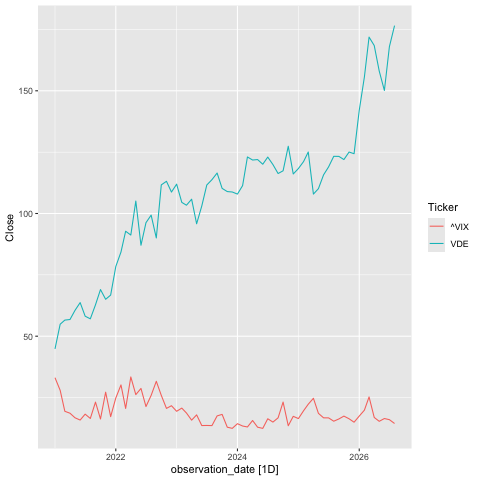

In [17]:
%%R
stock_ts <- tsibble(stock, key = Ticker)
stock_ts <- mutate(stock_ts, diff = difference(Close))
autoplot(stock_ts, Close)

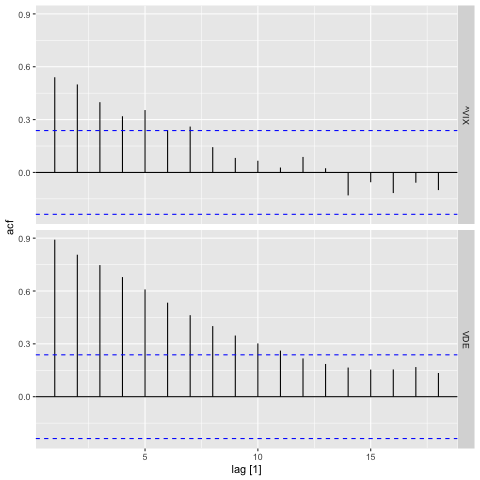

In [91]:
%%R
trading_day_ts <- mutate(stock_ts, trading_day = row_number()) %>%
update_tsibble(index = trading_day, regular = TRUE)
trading_day_ts %>% ACF(Close) %>% autoplot()

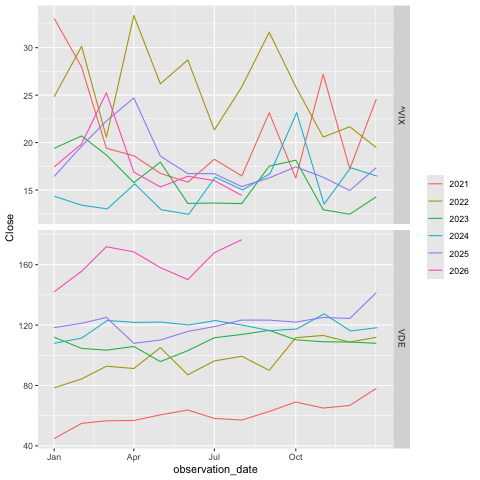

In [156]:
%%R
stock_ts_season <- fill_gaps(stock_ts) %>% mutate(Close = na.approx(Close))
gg_season(stock_ts_season, y=Close, period='year')
# use gg_season, period =5, trading day, start friday, 

In [ ]:
%%R
ts_visual_diag<- function(timeseries_data){
    autoplot(timeseries_data)
    ACF(timeseries_data)
    ggseasonplot(timeseries_data)
}

In [ ]:
%%R
read_csv <- function(folder_path){
  csv_files <- list.files(folder_path, pattern = "\\.csv$", full.names = TRUE)
  csv_data <- map(csv_files, read_csv) %>%
  list_rbind()
  return(csv_data)
}